# NYC 311 Complaint Analysis (2024–2025)

## Objective
Analyze NYC 311 service request data to identify how complaint volume and types changed between 2024 and 2025, and uncover trends that can inform resource allocation and city service improvements.
## Dataset
- NYC Open Data 311 Service Requests
- ~7 million rows
- Filtered to 2024–2025

## Tools Used
- Python (pandas)
- Jupyter Notebook
- Matplotlib
- AI-assisted development (ChatGPT) for debugging and optimization

## Data Loading & Cleaning

Due to the large dataset size (~7M rows), chunk processing was used to efficiently load and filter the data.

### Steps:
- Normalize column names
- Convert date fields
- Filter for 2024–2025
- Select only relevant columns

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "/Users/newworld/Downloads/RAW DATA 311_Service_Requests_from_2020_to_Present_20260329.csv"
out_path = "/Users/newworld/Downloads/311_2024_2025_clean.csv"

chunks = []

for chunk in pd.read_csv(
    file_path,
    chunksize=100000,
    usecols=[
        'Unique Key',
        'Created Date',
        'Problem (formerly Complaint Type)',
        'Problem Detail (formerly Descriptor)',
        'Borough'
    ]
):
    
    # Normalize column names
    chunk.columns = chunk.columns.str.strip().str.lower().str.replace(" ", "_")
    
    # Fix date parsing
    chunk['created_date'] = pd.to_datetime(
        chunk['created_date'],
        format='%m/%d/%Y %I:%M:%S %p',
        errors='coerce'
    )
    
    # Filter rows
    filtered = chunk[
        (chunk['created_date'] >= '2024-01-01') &
        (chunk['created_date'] <= '2025-12-31')
    ]
    
    # ✅ NOW select correct columns
    filtered = filtered[[
        'unique_key',
        'created_date',
        'problem_(formerly_complaint_type)',
        'problem_detail_(formerly_descriptor)',
        'borough'
    ]]
    
    # ✅ Rename columns for clean usage
    filtered = filtered.rename(columns={
        'problem_(formerly_complaint_type)': 'complaint_type',
        'problem_detail_(formerly_descriptor)': 'descriptor'
    })
    
    chunks.append(filtered)

# Combine all chunks
df = pd.concat(chunks, ignore_index=True)

# Save file
df.to_csv(out_path, index=False)

print("Done ✅")
print("Final shape:", df.shape)
print("Columns:", df.columns.tolist())

Done ✅
Final shape: (7102961, 5)
Columns: ['unique_key', 'created_date', 'complaint_type', 'descriptor', 'borough']


## Cleaned Dataset Overview

The dataset was successfully filtered to the target date range and reduced to the fields most relevant for analysis.

### Final Columns

- unique_key
- created_date
- complaint_type
- descriptor
- borough

## Feature Engineering: Complaint Grouping

Individual complaint types were grouped into broader business categories to simplify analysis and improve interpretability.

### Defined Categories

- Noise
- Housing
- Transportation
- Sanitation
- Utilities
- Infrastructure
- Encampment / Social
- Environment
- Other

Custom keyword-based logic was developed to map detailed complaint types into these broader categories.

In [2]:
def map_complaint_group(ct):
    if pd.isna(ct):
        return 'Other'

    ct = ct.lower()

    if 'noise' in ct:
        return 'Noise'

    elif any(x in ct for x in [
        'heat', 'hot water', 'plumbing', 'paint', 'plaster',
        'door', 'window', 'floor',
        'appliance', 'elevator', 'lead',
        'building', 'maintenance', 'facade', 'asbestos'
    ]):
        return 'Housing'

    elif any(x in ct for x in [
        'parking', 'driveway', 'traffic', 'vehicle', 'obstruction'
    ]):
        return 'Transportation'

    elif any(x in ct for x in [
        'sanitation', 'dirty', 'waste', 'dumping',
        'collection', 'rodent',
        'food', 'restaurant',
        'dead animal', 'residential disposal', 'graffiti'
    ]):
        return 'Sanitation'

    elif any(x in ct for x in [
        'water', 'leak', 'electric', 'sewer'
    ]):
        return 'Utilities'

    elif any(x in ct for x in [
        'street', 'sidewalk', 'condition', 'light',
        'snow', 'ice'
    ]):
        return 'Infrastructure'

    elif any(x in ct for x in [
        'encampment', 'homeless'
    ]):
        return 'Encampment / Social'

    elif 'tree' in ct:
        return 'Environment'

    else:
        return 'Other'

In [3]:
df['complaint_group'] = df['complaint_type'].apply(map_complaint_group)

## Grouping Results

Custom grouping logic was applied across all complaint records.

The "Other" category was iteratively reduced by refining classification rules, improving analytical clarity and category usefulness.

## Exploratory Data Analysis

This section examines complaint distribution across boroughs and complaint categories to identify concentration patterns and operational demand.

In [4]:
df.groupby(['borough', 'complaint_group']).size().unstack()

complaint_group,Encampment / Social,Environment,Housing,Infrastructure,Noise,Other,Sanitation,Transportation,Utilities
borough,,,,,,,,,
BRONX,8756,12916,420588,129448,492161,76373,65203,272250,94942
BROOKLYN,27097,52362,379746,188639,390100,121418,171338,679954,110203
MANHATTAN,113897,14016,293369,119005,373011,158641,99683,215718,58614
QUEENS,16861,58601,209664,159440,295644,133310,113379,626638,89612
STATEN ISLAND,913,17778,26650,38060,33655,17784,31369,65501,23411
Unspecified,18,104,44,649,67,2333,460,1527,41


## Data Visualization

This section explores how complaint volume changed over time, across boroughs, and across complaint categories between 2024 and 2025.

## How Did Complaint Trends Change Over Time?

Monthly trend analysis is used to evaluate changes in complaint activity throughout the two-year period.

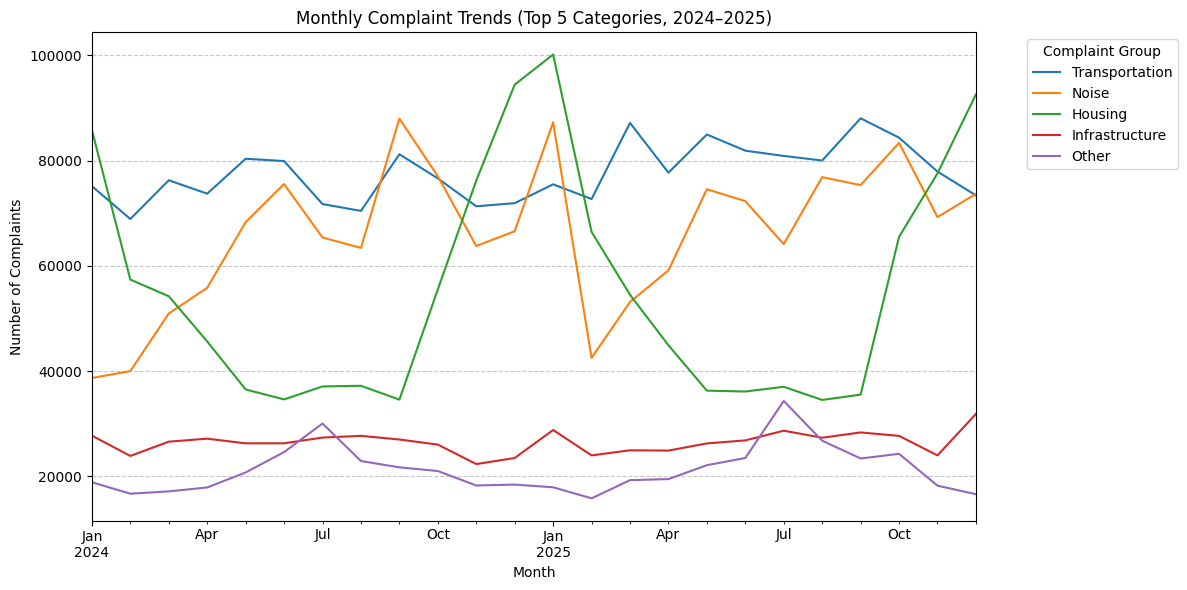

In [5]:
# Create month column
df['month'] = df['created_date'].dt.to_period('M')
# Create Year Column
df['year'] = df['created_date'].dt.year

# Group data
monthly = df.groupby(['month', 'complaint_group']).size().unstack()

# ✅ Select top 5 complaint groups overall
top_groups = df['complaint_group'].value_counts().head(5).index

# ✅ Plot only top 5
monthly[top_groups].plot(figsize=(12,6))

plt.title("Monthly Complaint Trends (Top 5 Categories, 2024–2025)")
plt.ylabel("Number of Complaints")
plt.xlabel("Month")


plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.legend(title="Complaint Group", bbox_to_anchor=(1.05, 1))

plt.tight_layout()

## How Do Complaint Patterns Differ by Borough?

These charts compare complaint volume and category mix across boroughs to highlight geographic differences in service demand.

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, 'BRONX'),
  Text(1, 0, 'BROOKLYN'),
  Text(2, 0, 'MANHATTAN'),
  Text(3, 0, 'QUEENS'),
  Text(4, 0, 'STATEN ISLAND'),
  Text(5, 0, 'Unspecified')])

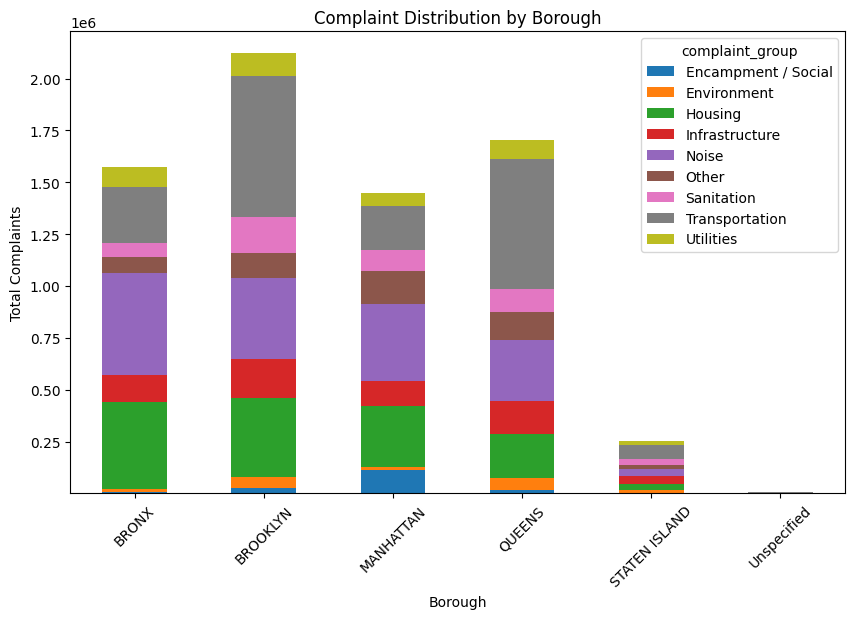

In [6]:
df.groupby(['borough', 'complaint_group']).size().unstack().plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title("Complaint Distribution by Borough")
plt.ylabel("Total Complaints")
plt.xlabel("Borough")
plt.xticks(rotation=45)

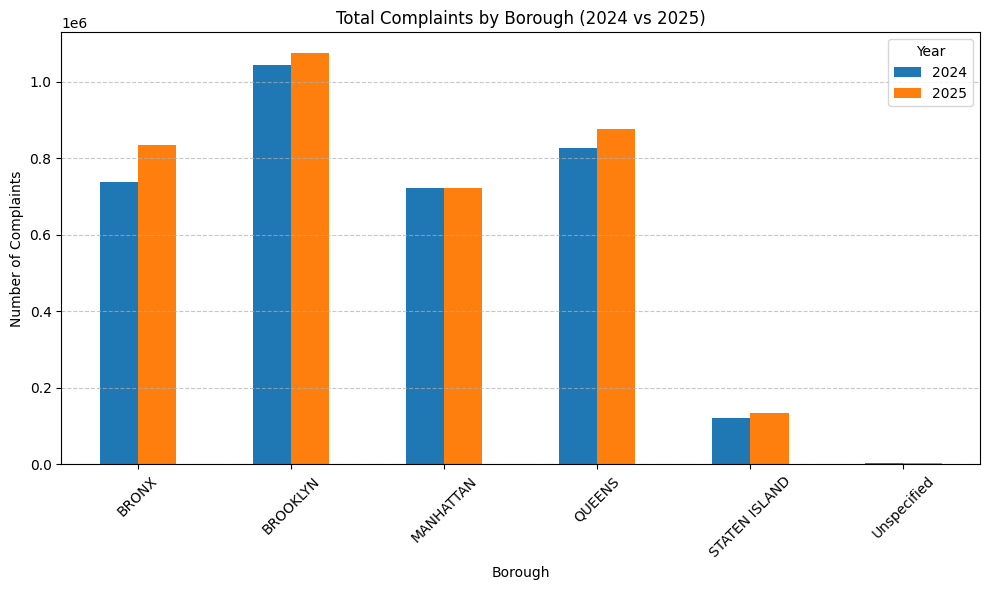

In [7]:
borough_year_total = df.groupby(['borough', 'year']).size().unstack()

borough_year_total.plot(
    kind='bar',
    figsize=(10,6)
)


plt.title("Total Complaints by Borough (2024 vs 2025)")
plt.ylabel("Number of Complaints")
plt.xlabel("Borough")
plt.xticks(rotation=45)
plt.legend(title="Year")

plt.grid(axis='y', linestyle='--', alpha=0.7)  # 👈 adds readability

plt.tight_layout()

These visualizations highlight clear differences in complaint distribution across boroughs and show year-over-year growth in categories such as Noise and Transportation.

## Which Complaint Categories Are Increasing or Decreasing?

Year-over-year comparisons were used to identify categories experiencing growth or decline between 2024 and 2025.

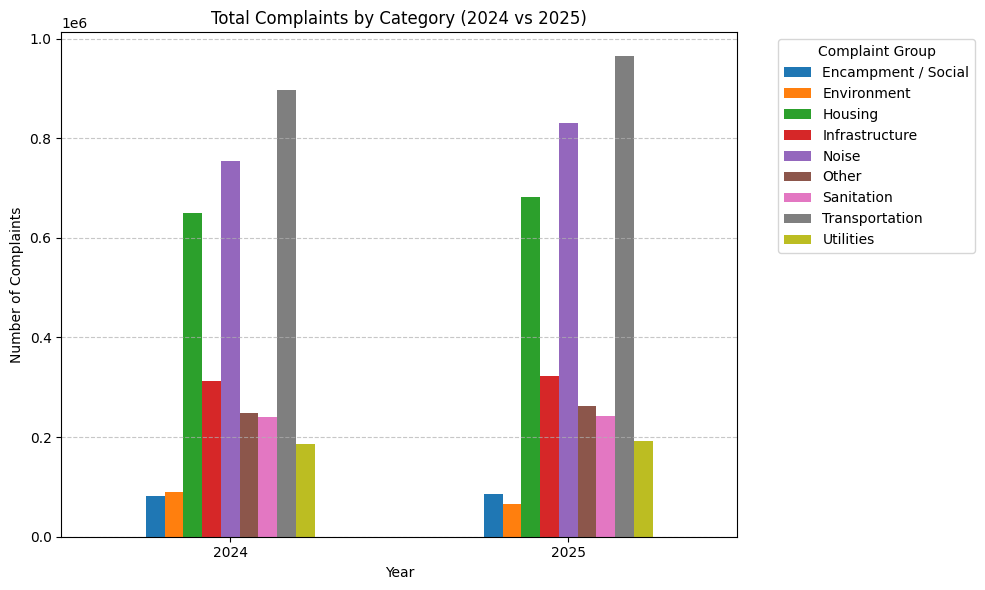

In [8]:
df['year'] = df['created_date'].dt.year

year_group = df.groupby(['year', 'complaint_group']).size().unstack()

year_group.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Total Complaints by Category (2024 vs 2025)")
plt.ylabel("Number of Complaints")
plt.xlabel("Year")

plt.xticks(rotation=0)

plt.legend(title="Complaint Group", bbox_to_anchor=(1.05, 1))

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

In [9]:
yearly = df.groupby(['year', 'complaint_group']).size().unstack()

growth = (yearly.loc[2025] - yearly.loc[2024]) / yearly.loc[2024]

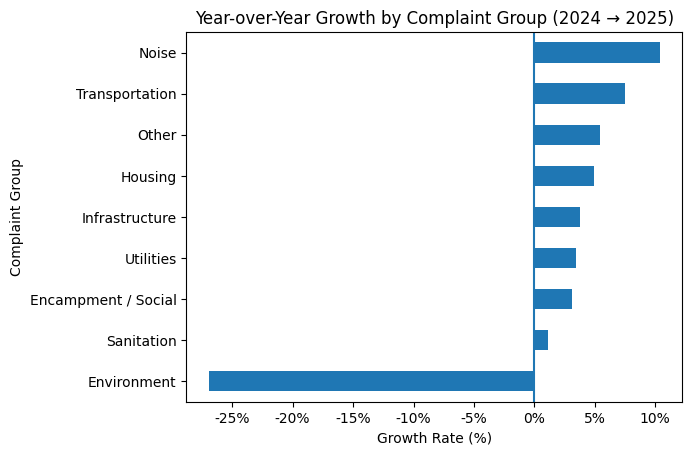

In [10]:
growth.sort_values().plot(kind='barh')

plt.axvline(0)
plt.title("Year-over-Year Growth by Complaint Group (2024 → 2025)")
plt.xlabel("Growth Rate (%)")
plt.ylabel("Complaint Group")
plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.0%}')
)

plt.show()

Noise and Transportation complaints experienced the strongest year-over-year growth, while Environment-related complaints declined significantly.

## What Issues Generate the Most Demand?

This chart highlights the most common complaint types across the dataset.

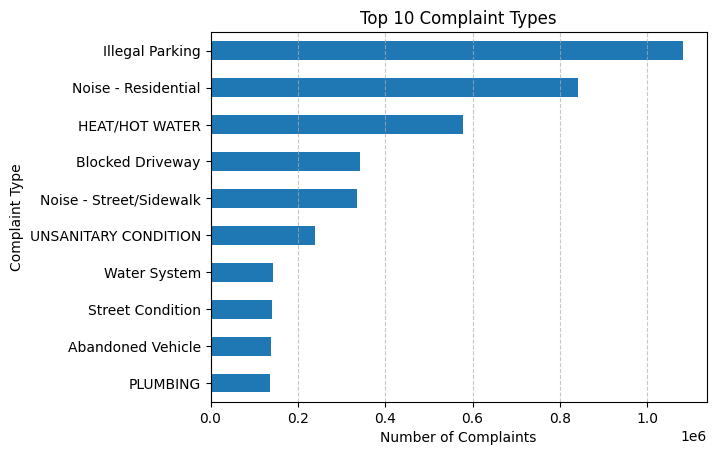

In [11]:
df['complaint_type'].value_counts().head(10).sort_values().plot(kind='barh')

plt.title("Top 10 Complaint Types")
plt.xlabel("Number of Complaints")
plt.ylabel("Complaint Type")

# 👇 ADD IT HERE TOO
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()


The most common complaint types were concentrated in Transportation, Noise, and Housing-related issues, including Heat/Hot Water complaints.

## Key Insights

- Noise complaints showed the strongest year-over-year growth.
- Transportation complaints remained the largest category across boroughs.
- Housing-related complaints remained consistently high, especially Heat/Hot Water issues.
- Environment-related complaints declined in 2025.
- Python chunking enabled efficient processing of a multi-million-row dataset.

## Conclusion

This project demonstrates the ability to:

- Clean and process large-scale public datasets
- Engineer meaningful analytical features
- Perform structured exploratory analysis
- Build effective visualizations
- Generate insights from real-world operational data
- Adapt workflows when scale exceeds spreadsheet-based tools